In [3]:
from imports import *
# ========================================================================================================================================================
# ================================================================CODE SNIPPETS===========================================================================
# ========================================================================================================================================================
# for a in cm._cmap_names_categorical:
#     display(cm.__dict__[a].resampled(4))
# # ======================================================================================================================================================
# # ======================================================================================================================================================
# for (Event,Station,Metrics,Comp) in OBS_Generator(catalog,dirs['Py_DataParentFolder']):
#     print(Event)
# for i,(Event,Station,Metrics,Comp) in zip(range(1),OBS_Generator(catalog,dirs['Py_DataParentFolder'])):
#     print(Event)
# # ======================================================================================================================================================
# # ======================================================================================================================================================
def smooth(d,k=10):return np.convolve(d, np.ones(k) / k, mode='same')
NoiseColors = [mcolors.to_hex(m) for m in [cm.__dict__[e].resampled(30).resampled(6).colors for e in ['devon_categorical']][0]]
# [display(c) for c in [cm.__dict__[e].resampled(70).resampled(5) for e in ['nuuk_categorical','devon_categorical','hawaii_categorical','imola_categorical','lapaz_categorical']]]
# np.array([[mcolors.to_hex(c) for c in r] for r in [cm.__dict__[e].resampled(70).resampled(5).colors for e in ['nuuk_categorical','devon_categorical','hawaii_categorical','imola_categorical','lapaz_categorical']]])


display(catalog)

,index,Station,Network,Latitude,Longitude,Experiment,Instrument_Design,Seismometer,Environment,Pressure_Gauge,...,n_events,Magnitude_mw,Origin,Metadata,Averaging,Events,Files,Depth_KM,Network_Experiment,StaName
0,22,M08A,7D,44.118698,-124.895302,CASCADIA INITIATIVE,AB,Trillium Compact,North Pacific,DPG,...,2,"[6.6, 6.3]","[[resource_id, time, time_errors, longitude, l...","[[resource_id, event_type, event_type_certaint...",[],"[2012.069.07.09, 2012.181.21.07]",[],"[33.7, 17.1]",[7D] CASCADIA INITIATIVE,7D.M08A
1,23,M07A,7D,44.898701,-125.116798,CASCADIA INITIATIVE,AB,Trillium Compact,North Pacific,DPG,...,2,"[6.6, 6.3]","[[resource_id, time, time_errors, longitude, l...","[[resource_id, event_type, event_type_certaint...",[],"[2012.069.07.09, 2012.181.21.07]",[],"[33.7, 17.1]",[7D] CASCADIA INITIATIVE,7D.M07A


In [9]:
def plot_spec_coh_adm_ph(Metrics):
    pairs = ['ZP']
    meters = ['psd','Coherence','Admittance','Phase']
    fig, axes = plt.subplots(nrows=4, ncols=1,figsize=(8,10),layout='constrained',squeeze=False,sharey='row',sharex='all')
    axes = axes.reshape(-1)
    stam = Metrics['ATaCR'].traces[0].stats.network + '.' + Metrics['ATaCR'].traces[0].stats.station
    label = Metrics['ATaCR'].traces.select(channel='*Z')[0].stats.location
    Pre = Metrics['Raw']
    Post = Metrics['ATaCR']
    Noise = Metrics['Noise']
    fn = fnotch(abs(Post.traces[0].stats.sac.stel*1000))
    tstamp = Pre.traces[0].stats.starttime.strftime('%Y.%j.%H.%M')
    for pi,(ax,m) in enumerate(zip(axes,meters)):
        if m=='psd':
            p = 'Z'
        else:
            p = pairs[0]
        evf,prey = Pre.__getattribute__(m)(p)
        evf,posty = Post.__getattribute__(m)(p)
        if m=='psd':
            noisef,noisey = Noise.f,Noise.StaNoise.power.__dict__['cZZ']
        else:
            noisef,noisey = Noise.__getattribute__(m)(p)
        noisey = noisey[noisef>0]
        noisef = noisef[noisef>0]
        if m=='psd':
            noisey = 10*np.log10(noisey)
            prey = 10*np.log10(prey)
            posty = 10*np.log10(posty)
        ax.scatter(noisef,noisey,s=0.5,c='gray',label='Noise')
        if pi==0:
            lbl = stam + ' | ' + label + ' ' + tstamp + ' | '
        else:
            lbl = ''
        ax.set_xlabel('Frequency')
        ax.set_ylabel(m.replace('psd','Power Density'))
        ax.set_title(lbl + p + '-' + m.replace('psd','PSD'),fontweight='bold')
        ax.scatter(evf,prey,c='k',label='PRE',marker='o',s=1)
        ax.scatter(evf,posty,c='m',label='POST',marker='o',s=0.5)
        ax.axvline(fn,linewidth=0.2,color='k')
        if pi==0:
            ax.text(fn*1.05,0.99*min(ax.get_ylim()),'Fn:' + str(round(1/fn*100)/100) + 's',alpha=0.4)
            ax.set_xscale('log')
            ax.set_xlim(evf[1],evf[-1])
            ax.legend(markerscale=10,ncols=len(meters))
    plt.tight_layout()
    return fig

[0/2] 7D.M08A.m6.6.z34km.2012.069.07.09.ATACR_SPECCOHPHADM.png


/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_86909/1414528050.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


[1/2] 7D.M08A.m6.3.z17km.2012.181.21.07.ATACR_SPECCOHPHADM.png


/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_86909/1414528050.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


[0/2] 7D.M07A.m6.6.z34km.2012.069.07.09.ATACR_SPECCOHPHADM.png


/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_86909/1414528050.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


[1/2] 7D.M07A.m6.3.z17km.2012.181.21.07.ATACR_SPECCOHPHADM.png


/var/folders/4c/3xb25hld3w73hv1lxgbg7r9m0000gn/T/ipykernel_86909/1414528050.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


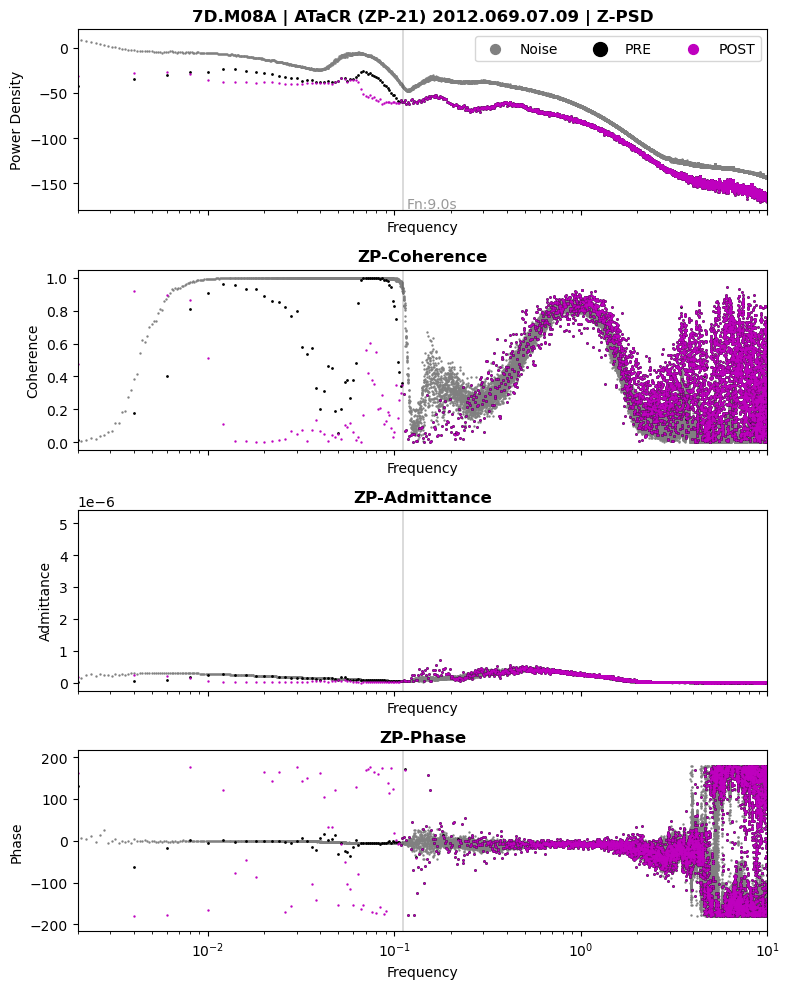

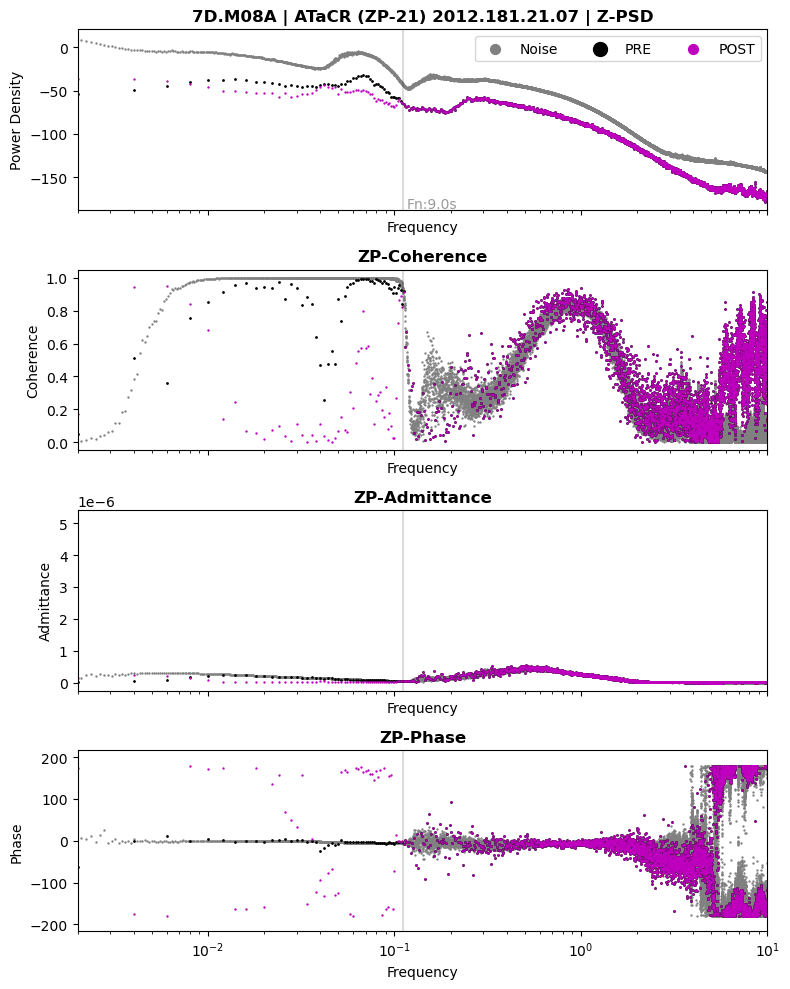

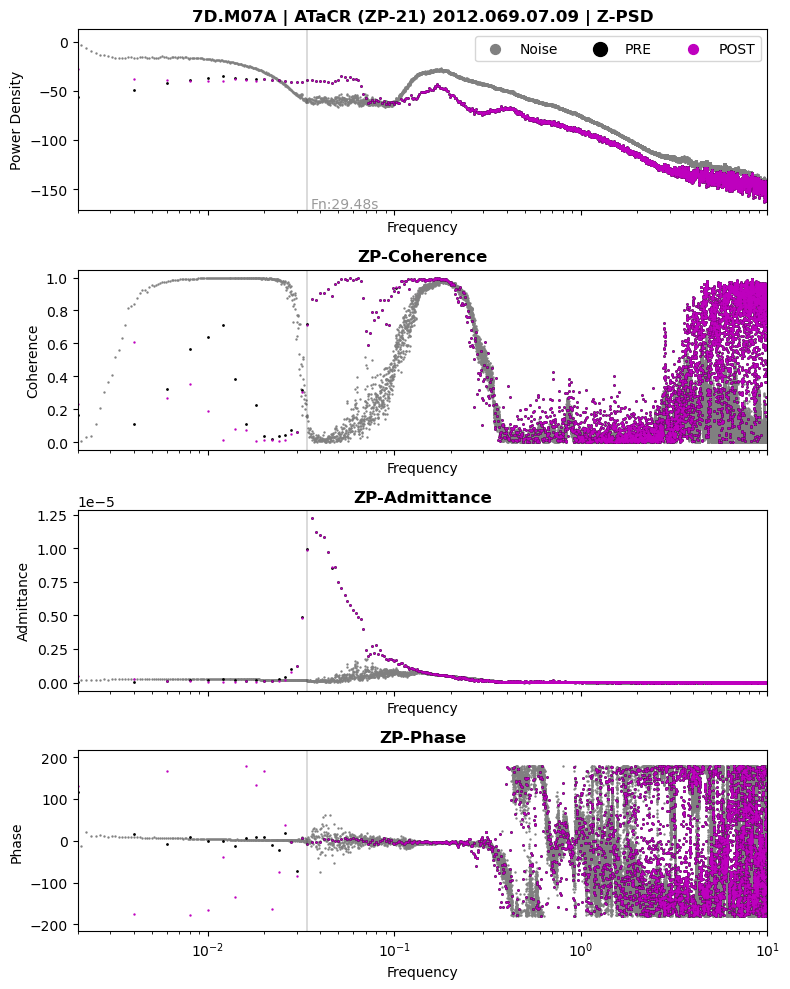

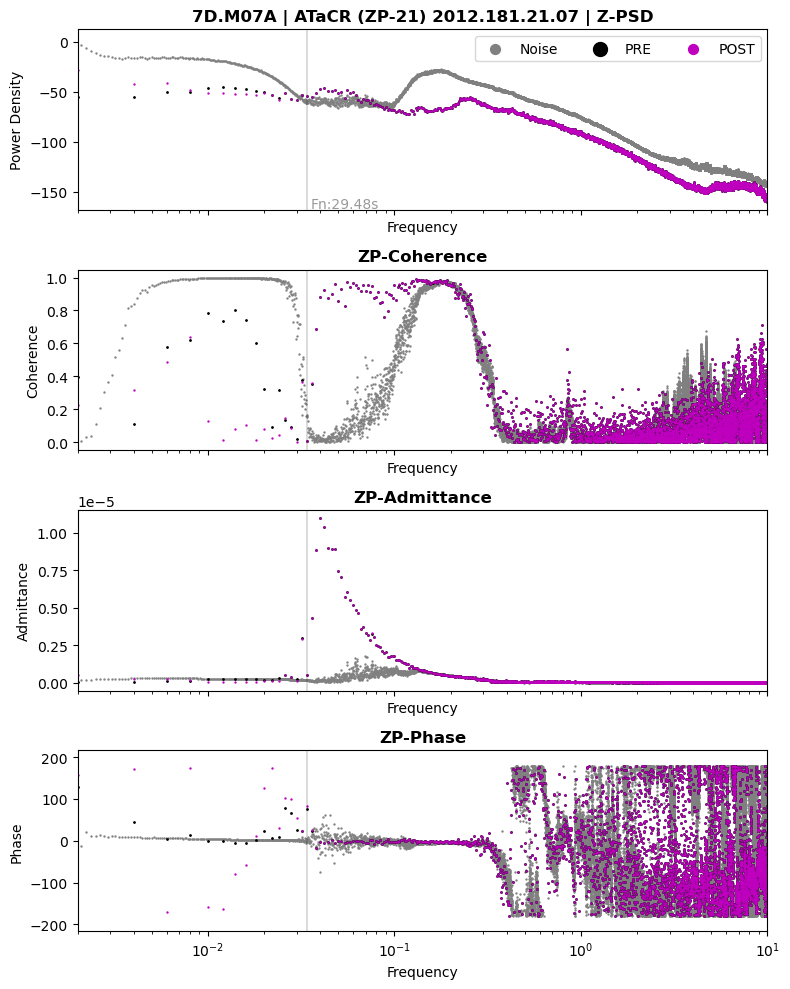

In [10]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++ CONSTRUCTOR AREA ++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
methods = ['PostATACR']
atacrdatafolder = archive / 'ATaCR_Data' / 'ATaCR_Python'
for correction_method in methods:
    coh_comp = correction_method.replace('PostHPS','HPS').replace('PostATACR','ATaCR')
    if correction_method=='PostHPS':
      return_hps = True
    else:
      return_hps = False
    OutFolder = Path(plotfolder)
    SubFolders = Path('EventRecords') / correction_method / 'coherence'
    OutFolder = OutFolder / SubFolders
    OutFolder.mkdir(parents=True,exist_ok=True)
    for station in catalog.iloc:
      stations = [station.Station]
      networks = [station.Network]
      events = station.Events
      for i,(net,sta) in enumerate(zip(networks,stations)):
        Metrics = []
        for evi,event in enumerate(events):
          depth = round(station.Metadata[evi].origins[0].depth/1000)
          mag = station.Metadata[evi].magnitudes[0].mag
          File = '.'.join([net,sta]) + '.m' + str(mag) + '.z' + str(depth) + 'km' + '.' + event + '.' + correction_method.replace('Post','') + '_SPECCOHPHADM.png'
          title = File.replace('_',' | ').replace('z','z: ').replace('m','mag: m')
          print('[' + str(evi) + '/' + str(len(events)) + '] ' + File)
          post_record = Stream()
          pre_record = Stream()
          M,Comp = get_metrics_comp(net,sta,atacrdatafolder,event,return_hps=return_hps,events_folder='EVENTS')
          # M['Noise'] = get_Noise(atacrdatafolder,net,sta,'sta')['Noise']
          Metrics.append(M.copy())
          fig = plot_spec_coh_adm_ph(M)
          save_tight(str(plotfolder / 'MeetingFigs' / 'SPECCOHPHADM' / File),fig,dpi=600)
